In [11]:
# устанавливаем зависимости
!pip install requirements.txt

In [33]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

import evaluate
import accelerate
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel
from tqdm.auto import tqdm

In [13]:
# Возьмем датасет
dataset = load_dataset('Mnwa/russian-toxic')

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 278021
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 69506
    })
})


In [14]:
print(dataset['train'][1])

# 0 - текст негативный
# 1 - текст положительный или нейтральный

{'text': 'на исходном фото надпись: вот так наша бабуля встречает гостей...', 'label': 1}


In [15]:
# Загрузим модель и токенайзер

tokenizer = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny2")

bert_model = AutoModel.from_pretrained("cointegrated/rubert-tiny2")

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [16]:
print(bert_model.config)

BertConfig {
  "add_cross_attention": false,
  "architectures": [
    "BertForPreTraining"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "dtype": "float32",
  "emb_size": 312,
  "eos_token_id": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 312,
  "initializer_range": 0.02,
  "intermediate_size": 600,
  "is_decoder": false,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 2048,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 3,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "tie_word_embeddings": true,
  "transformers_version": "5.0.0",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 83828
}



In [17]:
# Пишем кастомный класс Dataset для текстов
class ToxicDataset(Dataset):
    def __init__(self, hf_dataset, tokenizer, max_length=128, batch_size=1024):
        self.labels = hf_dataset['label']
        texts = [str(t) for t in hf_dataset['text']]

        input_ids_list = []
        attention_mask_list = []

        for i in tqdm(range(0, len(texts), batch_size), desc="Токенизация датасета"):
            batch_texts = texts[i : i + batch_size]

            encoding = tokenizer(
                batch_texts,
                add_special_tokens=True,
                max_length=max_length,
                padding='max_length',
                truncation=True,
                return_tensors='pt'
            )
            input_ids_list.append(encoding['input_ids'])
            attention_mask_list.append(encoding['attention_mask'])

        self.input_ids = torch.cat(input_ids_list, dim=0)
        self.attention_mask = torch.cat(attention_mask_list, dim=0)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [18]:
# Создаем датасеты и оборачиваем в dataloder

train_dataset = ToxicDataset(dataset['train'], tokenizer)
val_dataset = ToxicDataset(dataset['test'], tokenizer)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

Токенизация датасета:   0%|          | 0/272 [00:00<?, ?it/s]

Токенизация датасета:   0%|          | 0/68 [00:00<?, ?it/s]

In [19]:
# напишем архитектуру для нашей модели

class BertClassifier(nn.Module):
  def __init__(self, n_classes=2):
    super().__init__()

    self.bert = AutoModel.from_pretrained("cointegrated/rubert-tiny2")

    self.classifier = nn.Linear(312, n_classes)

  def forward(self, input_ids, attention_mask):

    outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)

    cls_output = outputs.last_hidden_state[:, 0, :]

    logits = self.classifier(cls_output)

    return logits

In [20]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [21]:
# Загружаем модель
model = BertClassifier().to(device)

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [22]:
# Задаем оптимизатор, функцию потерь

optimizer = AdamW(model.parameters(), lr=2e-5)

loss_fn = nn.CrossEntropyLoss()

In [34]:
# Пишем функцию обучения
def train(model, train_loader, optimizer, loss_fn, device, epochs=3):
    print(f"Начинаем обучение на {device}...")

    history = {'loss': [], 'acc': []}

    for epoch in range(epochs):
        print(f"\n--- Эпоха {epoch + 1}/{epochs} ---")
        model.train()

        total_loss = 0.0
        correct = 0
        total = 0

        progress_bar = tqdm(train_loader, desc=f"Эпоха {epoch+1}")

        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()

            batch_loss = loss.item()
            pred = outputs.argmax(dim=1)
            batch_correct = (pred == labels).sum().item()
            batch_total = labels.size(0)
            batch_acc = (batch_correct / batch_total) * 100

            total_loss += batch_loss
            correct += batch_correct
            total += batch_total

            progress_bar.set_postfix({
                'batch_loss': f"{batch_loss:.4f}",
                'batch_acc': f"{batch_acc:.2f}%"
            })

        epoch_loss = total_loss / len(train_loader)
        epoch_acc = (correct / total) * 100
        print(f"-> Итог Эпохи {epoch+1} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.2f}%\n")

        history['loss'].append(epoch_loss)
        history['acc'].append(epoch_acc)
    return history


In [35]:
history = train(model, train_loader, optimizer, loss_fn, device, epochs=3)

Начинаем обучение на cuda...

--- Эпоха 1/3 ---


Эпоха 1:   0%|          | 0/8689 [00:00<?, ?it/s]

-> Итог Эпохи 1 | Loss: 0.0669 | Acc: 97.61%


--- Эпоха 2/3 ---


Эпоха 2:   0%|          | 0/8689 [00:00<?, ?it/s]

-> Итог Эпохи 2 | Loss: 0.0534 | Acc: 98.14%


--- Эпоха 3/3 ---


Эпоха 3:   0%|          | 0/8689 [00:00<?, ?it/s]

-> Итог Эпохи 3 | Loss: 0.0442 | Acc: 98.46%



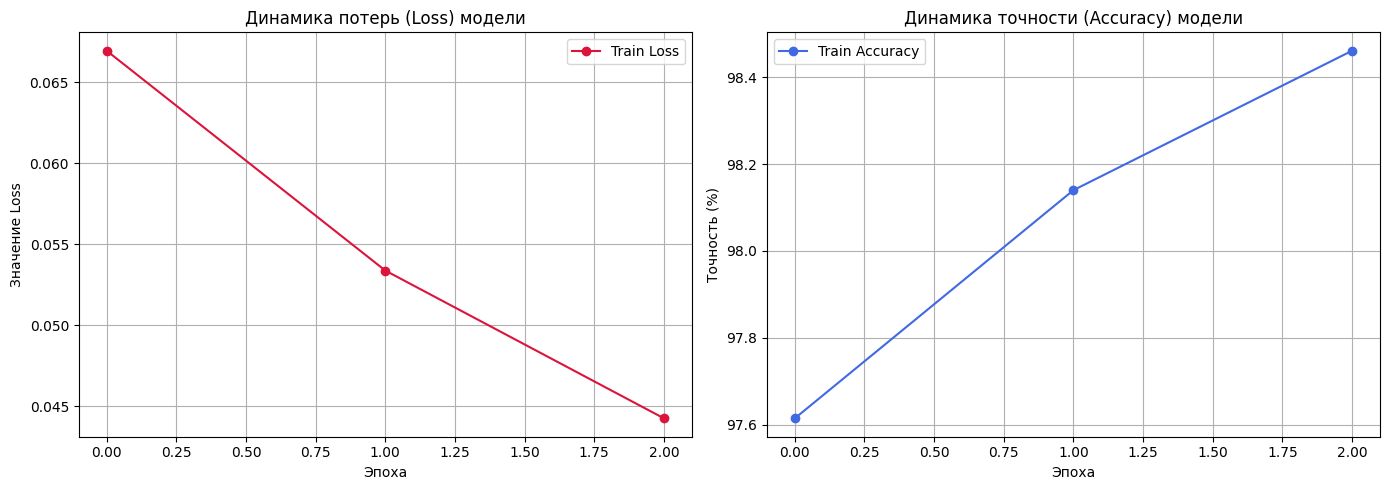

In [36]:
# Построим графики обучения

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history['loss'], marker='o', color='crimson', label='Train Loss')
plt.title('Динамика потерь (Loss) модели')
plt.xlabel('Эпоха')
plt.ylabel('Значение Loss')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['acc'], marker='o', color='royalblue', label='Train Accuracy')
plt.title('Динамика точности (Accuracy) модели')
plt.xlabel('Эпоха')
plt.ylabel('Точность (%)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [37]:
# Сохраняем веса модели

torch.save(model.state_dict(), 'bert_toxic_classifier.pt')
print("Веса модели успешно сохранены в файл 'bert_toxic_classifier.pt'!")

Веса модели успешно сохранены в файл 'bert_toxic_classifier.pt'!


In [38]:
# Пишем функцию валидации
def evaluate(model, data_loader, loss_fn, device):
  print(f"Начинаем валидацию модели...")
  model.eval()

  total_loss = 0.0
  correct = 0
  total = 0

  with torch.no_grad():

    progress_bar = tqdm(data_loader, desc="Валидация")

    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = model(input_ids, attention_mask)
        loss = loss_fn(outputs, labels)

        total_loss += loss.item()
        pred = outputs.argmax(dim=1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)

        progress_bar.set_postfix({
            'val_loss': f"{loss.item():.4f}",
        })

    final_loss = total_loss / len(data_loader)
    final_acc = (correct / total) * 100

    print("\n" + "="*30)
    print("Результаты: ")
    print(f"Средний Loss: {final_loss:.4f}")
    print(f"Точность (Accuracy): {final_acc:.2f}%")
    print("="*30 + "\n")

In [39]:
# Проводим валидацию

evaluate(model, val_loader, loss_fn, device)

Начинаем валидацию модели...


Валидация:   0%|          | 0/2173 [00:00<?, ?it/s]


Результаты: 
Средний Loss: 0.1466
Точность (Accuracy): 96.01%

